In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer = pd.read_csv("customer_churn.csv")

In [3]:
customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
customer.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
customer["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
customer["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [9]:
customer["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [10]:
customer["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [11]:
def fem_sencit_paymet():
    new_customer = []
    for i,row in customer.iterrows():
        if row["gender"] == "Female" and row["SeniorCitizen"] == 1 and row["PaymentMethod"] == "Mailed check":
            new_customer.append(row)
    return new_customer

new_customer = fem_sencit_paymet()
print(new_customer)
print(len(new_customer))

[customerID              0390-DCFDQ
gender                      Female
SeniorCitizen                    1
Partner                        Yes
Dependents                      No
tenure                           1
PhoneService                   Yes
MultipleLines                   No
InternetService        Fiber optic
OnlineSecurity                  No
OnlineBackup                    No
DeviceProtection                No
TechSupport                     No
StreamingTV                     No
StreamingMovies                 No
Contract            Month-to-month
PaperlessBilling               Yes
PaymentMethod         Mailed check
MonthlyCharges               70.45
TotalCharges                 70.45
Churn                          Yes
Name: 139, dtype: object, customerID              2656-FMOKZ
gender                      Female
SeniorCitizen                    1
Partner                         No
Dependents                      No
tenure                          15
PhoneService                

# or

In [12]:
female_senior_mailed = customer[
    (customer["gender"] == "Female") &
    (customer["SeniorCitizen"] == 1) &
    (customer["PaymentMethod"] == "Mailed check")
]
len(female_senior_mailed)

50

In [13]:
customer["TotalCharges"] = customer["TotalCharges"].replace(' ',np.nan)

low_tenure_or_charges = customer[
    (customer["tenure"] < 10) |
    (customer["TotalCharges"].astype(float) < 500)
]
len(low_tenure_or_charges)

2233

# part 2 visualization

Churn
No     5174
Yes    1869
Name: count, dtype: int64


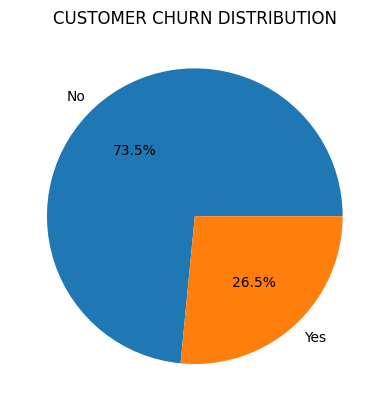

In [14]:
churn_counts = customer["Churn"].value_counts()
print(churn_counts)

plt.pie(churn_counts,
        labels = churn_counts.index,
        autopct= "%0.1f%%")
plt.title("CUSTOMER CHURN DISTRIBUTION")
plt.show()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


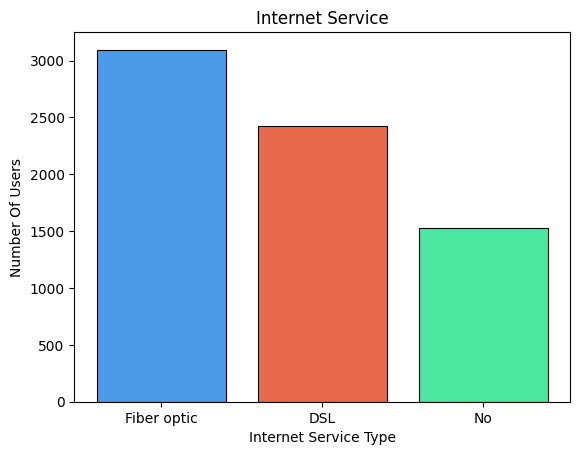

In [15]:
value = customer["InternetService"].value_counts()
print(value)

plt.bar(value.index, value,
        color = ["#4C9BE8", "#E8694C", "#4CE8A0"],  
        edgecolor = "black",                         
        linewidth = 0.8)

plt.xlabel("Internet Service Type")
plt.ylabel("Number Of Users")
plt.title("Internet Service")
plt.show()